<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:0'>Challenge 8 — RNN y LSTM para señales biomédicas</h2>
<h3 style='color:white; text-align:center; margin:0'>Versión STUDENT</h3>
</div>

**Curso:** Reconocimiento de Patrones — Ingeniería Biomédica  
**Módulo:** Deep Learning II  
**Tema:** Redes neuronales recurrentes, LSTM, secuencias biomédicas y métricas clínicas  
**Framework:** PyTorch

## Contexto clínico

En el Challenge 7 trabajaste con **imágenes biomédicas** y redes convolucionales. Ahora pasamos a un tipo de dato muy frecuente en Ingeniería Biomédica: **señales temporales**.

En este challenge se usará un dataset **sintético y didáctico** de segmentos ECG simulados. La tarea es clasificar cada segmento como:

- `0`: ritmo simulado normal
- `1`: ritmo simulado alterado

El objetivo no es hacer diagnóstico real, sino aprender cómo una red recurrente procesa una señal como secuencia y cómo interpretar sus métricas en un contexto biomédico.

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
🧑‍🎓 <b> completa los espacios en blanco, ejecuta el notebook y responde las preguntas clínicas.
</div>

---
## Ejercicio 1 — Diseño previo al código

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde antes de programar.
</div>

### 1.1 — ¿Por qué una señal biomédica es una secuencia?


**Respuesta:**  
Porque una señal biomédica como el ECG se registra como una serie de valores ordenados en el tiempo. El valor de la señal en un instante dado depende del contexto temporal previo (por ejemplo, la contracción ventricular ocurre después de la despolarización auricular), por lo que el orden secuencial contiene información fisiológica crítica que no puede ignorarse al modelarla.

### 1.2 — MLP vs RNN/LSTM


| Modelo | ¿Cómo recibe la señal? | ¿Modela explícitamente el orden temporal? |
|--------|-------------------------|------------------------------------------|
| MLP | Aplanada como vector de características | No asume orden temporal |
| RNN | Paso a paso (secuencialmente) | Sí, con memoria a corto plazo |
| LSTM | Paso a paso con compuertas lógicas | Sí, con memoria a corto y largo plazo |

### 1.3 — Pipeline completo


```text
Señal ECG sintética
      │
      ▼
[ Paso A ] Adquisición o generación del dataset sintético
      │
      ▼
[ Paso B ] Preprocesamiento (normalización, limpieza de ruido)
      │
      ▼
[ Paso C ] División en Train, Validation y Test
      │
      ▼
[ Paso D ] Formateo a secuencias (batch, seq_len, input_size) y DataLoaders
      │
      ▼
[ Paso E ] Definición de la arquitectura del modelo (MLP, RNN o LSTM)
      │
      ▼
[ Paso F ] Entrenamiento (Forward pass, cálculo de Loss, Backpropagation, Optimización)
      │
      ▼
[ Paso G ] Evaluación y predicción de probabilidades sobre conjunto de test
      │
      ▼
[ Paso H ] Análisis de métricas clínicas y elección de umbral diagnóstico
```

---
## Ejercicio 2 — Setup y generación de señales

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esta sección durante la sesión.
</div>

### Paso 2.1 — Librerías y configuración

In [1]:
# ── Estilo visual y configuración general ───────────────────────
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

# TODO 1: importa PyTorch y sus módulos principales.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(1)

# TODO 2: selecciona GPU si está disponible; si no, CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)

Device: cpu


### Paso 2.2 — Generación del dataset sintético

Trabajaremos con señales simuladas para evitar dependencias externas. Cada muestra es un segmento temporal de longitud 100.

> Nota: las señales son sintéticas y solo tienen finalidad docente.

In [2]:
def gaussian(t, mu, sigma, amp):
    # Pulso gaussiano simple para simular ondas tipo ECG.
    return amp * np.exp(-0.5 * ((t - mu) / sigma) ** 2)


def generate_ecg_like_segment(label, length=100, rng=None):
    # Dataset sintético y didáctico. No debe usarse para diagnóstico real.
    if rng is None:
        rng = np.random.default_rng()

    t = np.linspace(0, 1, length)
    signal = np.zeros_like(t)
    jitter = rng.normal(0, 0.012)
    r_amp = rng.normal(1.0, 0.08)
    noise_level = rng.uniform(0.015, 0.04)

    if label == 0:
        signal += gaussian(t, 0.20 + jitter, 0.035, 0.12)
        signal += gaussian(t, 0.39 + jitter, 0.012, -0.18)
        signal += gaussian(t, 0.42 + jitter, 0.010, r_amp)
        signal += gaussian(t, 0.45 + jitter, 0.014, -0.25)
        signal += gaussian(t, 0.66 + jitter, 0.060, 0.32)
    else:
        signal += gaussian(t, 0.18 + jitter, 0.040, rng.normal(0.08, 0.03))
        signal += gaussian(t, 0.38 + jitter, 0.020, -0.12)
        signal += gaussian(t, 0.43 + jitter, 0.024, rng.normal(0.75, 0.12))
        signal += gaussian(t, 0.48 + jitter, 0.026, -0.20)
        signal += gaussian(t, 0.68 + jitter, 0.070, rng.normal(-0.18, 0.06))
        if rng.random() < 0.55:
            signal += gaussian(t, rng.uniform(0.70, 0.82), 0.020, rng.normal(0.35, 0.08))

    baseline = 0.03 * np.sin(2 * np.pi * rng.uniform(0.8, 1.3) * t + rng.uniform(0, 2*np.pi))
    noise = rng.normal(0, noise_level, size=length)
    signal = signal + baseline + noise
    signal = (signal - signal.mean()) / (signal.std() + 1e-8)
    return signal.astype(np.float32)


def make_dataset(n_samples=900, length=100, abnormal_ratio=0.42, seed=42):
    rng = np.random.default_rng(seed)
    y = rng.choice([0, 1], size=n_samples, p=[1 - abnormal_ratio, abnormal_ratio])
    X = np.stack([generate_ecg_like_segment(int(label), length, rng) for label in y])
    return X.astype(np.float32), y.astype(np.int64)

# TODO 3: genera el dataset sintético.
X, y = make_dataset(n_samples=900, length=100, abnormal_ratio=0.42, seed=SEED)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Clase 0 = normal simulado:', np.sum(y == 0))
print('Clase 1 = alterado simulado:', np.sum(y == 1))

X shape: (900, 100)
y shape: (900,)
Clase 0 = normal simulado: 515
Clase 1 = alterado simulado: 385


### Paso 2.3 — Visualización inicial de señales

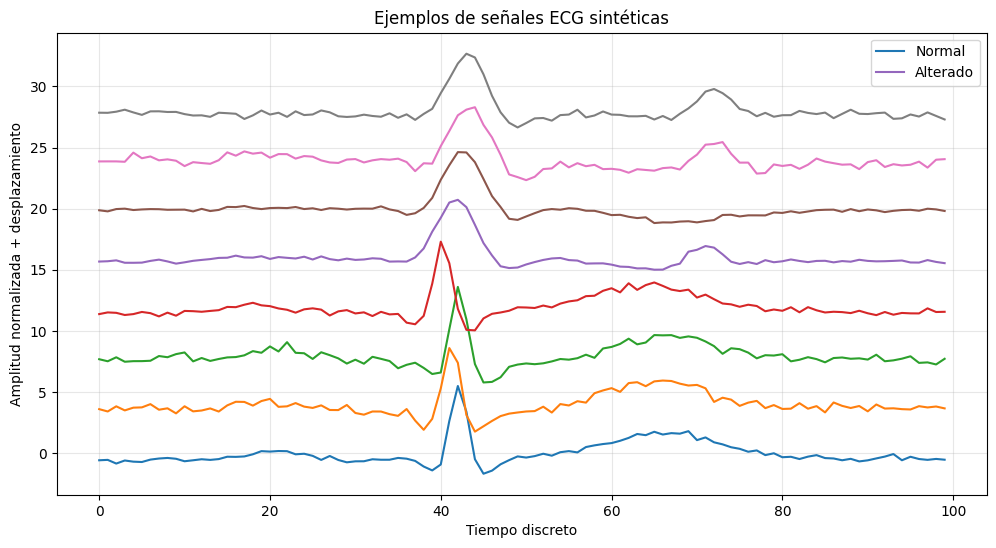

In [3]:
idx_normal = np.where(y == 0)[0][:4]
idx_abnormal = np.where(y == 1)[0][:4]

t = np.arange(X.shape[1])
plt.figure(figsize=(12, 6))
for i, idx in enumerate(idx_normal):
    plt.plot(t, X[idx] + i * 4, label='Normal' if i == 0 else None)
for i, idx in enumerate(idx_abnormal):
    plt.plot(t, X[idx] + (i + 4) * 4, label='Alterado' if i == 0 else None)
plt.title('Ejemplos de señales ECG sintéticas')
plt.xlabel('Tiempo discreto')
plt.ylabel('Amplitud normalizada + desplazamiento')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Ejercicio 3 — Formato secuencial y DataLoader

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — observa cuidadosamente la forma de los datos.
</div>

Para una RNN/LSTM en PyTorch con `batch_first=True`, la entrada debe tener forma:

```text
(batch, sequence_length, input_size)
```

En este caso:

- `batch`: número de señales por mini-batch
- `sequence_length`: número de muestras temporales
- `input_size`: número de canales de entrada por instante temporal

In [4]:
# TODO 4: divide el dataset en trainval y test de forma estratificada.
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=SEED)

# TODO 5: divide trainval en train y validation de forma estratificada.
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.176, stratify=y_trainval, random_state=SEED)

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

# TODO 6: agrega una dimensión final a X para representar input_size=1.
X_train_seq = np.expand_dims(X_train, axis=-1)
X_val_seq   = np.expand_dims(X_val, axis=-1)
X_test_seq  = np.expand_dims(X_test, axis=-1)

# TODO 7: convierte arreglos NumPy a tensores de PyTorch.
X_train_t = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_t = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

batch_size = 64
# TODO 8: crea TensorDataset y DataLoader para train, val y test.
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Batch X:', xb.shape)
print('Batch y:', yb.shape)

Train: (630, 100) Val: (135, 100) Test: (135, 100)
Batch X: torch.Size([64, 100, 1])
Batch y: torch.Size([64, 1])


---
## Ejercicio 4 — Funciones de entrenamiento y evaluación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — identifica dónde ocurre forward pass, loss, backpropagation y actualización de pesos.
</div>

In [5]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # TODO 9: completa el ciclo de entrenamiento de PyTorch.
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X_batch.size(0)
    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            running_loss += loss.item() * X_batch.size(0)
    return running_loss / len(loader.dataset)


def fit_model(model, train_loader, val_loader, epochs=4, lr=1e-3):
    model = model.to(device)
    # TODO 10: define función de pérdida y optimizador.
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, loss_fn, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')
    return model, history


def predict_proba(model, loader, device):
    model.eval()
    probs_all = []
    y_all = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            # TODO 11: convierte logits en probabilidades.
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_all.extend(probs)
            y_all.extend(y_batch.numpy().ravel())
    return np.array(y_all).astype(int), np.array(probs_all)


def clinical_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'sensitivity_recall': recall_score(y_true, y_pred, zero_division=0),
        # TODO 12: completa especificidad.
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': roc_auc_score(y_true, y_proba),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }


def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history['train_loss'], label='Train loss')
    plt.plot(history['val_loss'], label='Validation loss')
    plt.title(title)
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

---
## Ejercicio 5 — Baseline MLP

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — este modelo sirve como comparación base.
</div>

El MLP aplana la señal y la trata como un vector de características. Esto permite clasificar, pero pierde una representación explícita del orden temporal.

SequenceMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100, out_features=48, bias=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=1, bias=True)
  )
)
Parámetros entrenables: 4897
Epoch 01/4 | train_loss=0.5649 | val_loss=0.4154
Epoch 02/4 | train_loss=0.3190 | val_loss=0.2306
Epoch 03/4 | train_loss=0.1693 | val_loss=0.1229
Epoch 04/4 | train_loss=0.0885 | val_loss=0.0689


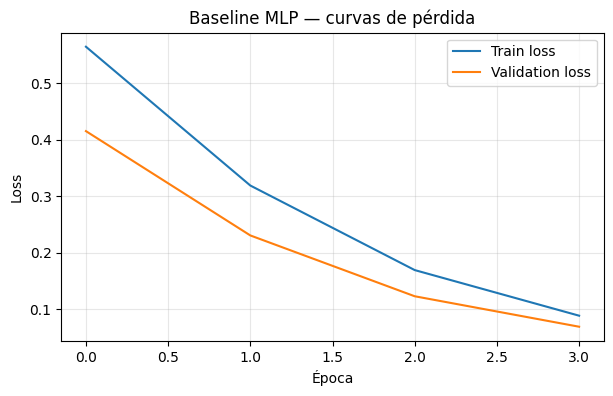

In [6]:
class SequenceMLP(nn.Module):
    # Baseline que aplana la señal temporal.
    def __init__(self, seq_len=100, hidden_dim=48):
        super().__init__()
        self.net = nn.Sequential(
            # TODO 13: aplana la entrada y define dos capas lineales con ReLU.
            nn.Flatten(),
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # TODO 14: devuelve la salida de la red.
        return self.net(x)

mlp = SequenceMLP(seq_len=X.shape[1], hidden_dim=48)
print(mlp)
print('Parámetros entrenables:', sum(p.numel() for p in mlp.parameters() if p.requires_grad))

mlp, hist_mlp = fit_model(mlp, train_loader, val_loader, epochs=4, lr=1e-3)
plot_history(hist_mlp, 'Baseline MLP — curvas de pérdida')

---
## Ejercicio 6 — RNN simple

<div style='background:#ede7f6; padding:8px 14px; border-left:4px solid #6a1b9a; border-radius:4px; margin:8px 0'>
🏠 <b>PARA CASA</b> — completa y entrena la RNN simple.
</div>

Una RNN procesa la señal paso a paso y actualiza un estado oculto. Ese estado resume información previa de la secuencia.

SimpleRNNClassifier(
  (rnn): RNN(1, 16, batch_first=True)
  (classifier): Linear(in_features=16, out_features=1, bias=True)
)
Parámetros entrenables: 321
Epoch 01/4 | train_loss=0.6720 | val_loss=0.6668
Epoch 02/4 | train_loss=0.6621 | val_loss=0.6536
Epoch 03/4 | train_loss=0.6471 | val_loss=0.6304
Epoch 04/4 | train_loss=0.6127 | val_loss=0.5701


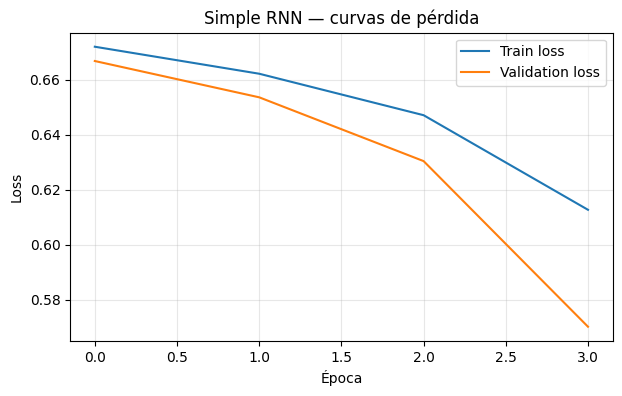

In [7]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        # TODO 15: define una RNN simple.
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        # TODO 16: define el clasificador final.
        self.classifier = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # TODO 17: completa el forward de la RNN.
        output, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        logits = self.classifier(last_hidden)
        return logits

rnn = SimpleRNNClassifier(input_size=1, hidden_size=16)
print(rnn)
print('Parámetros entrenables:', sum(p.numel() for p in rnn.parameters() if p.requires_grad))

rnn, hist_rnn = fit_model(rnn, train_loader, val_loader, epochs=4, lr=1e-3)
plot_history(hist_rnn, 'Simple RNN — curvas de pérdida')

---
## Ejercicio 7 — LSTM

<div style='background:#ede7f6; padding:8px 14px; border-left:4px solid #6a1b9a; border-radius:4px; margin:8px 0'>
🏠 <b>PARA CASA</b> — entrena la LSTM y compárala con el MLP y la RNN simple.
</div>

La LSTM incorpora una memoria interna y compuertas que permiten conservar u olvidar información temporal. En este challenge se entrena algunas épocas más que el MLP/RNN para evitar que, con pocas épocas, el modelo quede sesgado a predecir solo la clase normal con umbral 0.5.

LSTMClassifier(
  (lstm): LSTM(1, 16, batch_first=True)
  (classifier): Linear(in_features=16, out_features=1, bias=True)
)
Parámetros entrenables: 1233
Epoch 01/8 | train_loss=0.6901 | val_loss=0.6842
Epoch 02/8 | train_loss=0.6800 | val_loss=0.6752
Epoch 03/8 | train_loss=0.6710 | val_loss=0.6659
Epoch 04/8 | train_loss=0.6611 | val_loss=0.6501
Epoch 05/8 | train_loss=0.6369 | val_loss=0.6094
Epoch 06/8 | train_loss=0.5934 | val_loss=0.5537
Epoch 07/8 | train_loss=0.5297 | val_loss=0.4616
Epoch 08/8 | train_loss=0.4262 | val_loss=0.3335


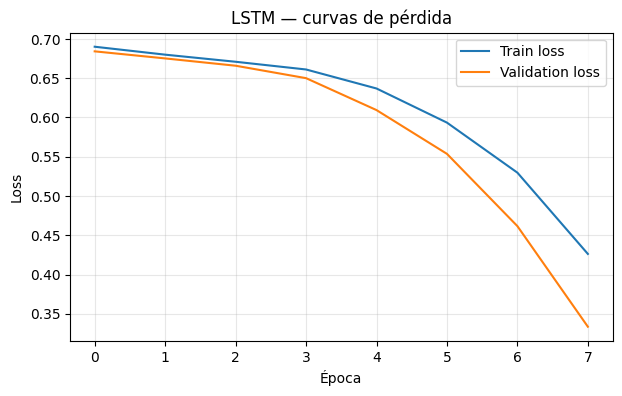

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        # TODO 18: define una LSTM.
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        # TODO 19: define el clasificador final.
        self.classifier = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # TODO 20: completa el forward de la LSTM.
        output, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]
        logits = self.classifier(last_hidden)
        return logits

lstm = LSTMClassifier(input_size=1, hidden_size=16)
print(lstm)
print('Parámetros entrenables:', sum(p.numel() for p in lstm.parameters() if p.requires_grad))

# Nota: se usan más épocas y un learning rate ligeramente mayor para que la LSTM aprenda mejor con este dataset.
lstm, hist_lstm = fit_model(lstm, train_loader, val_loader, epochs=8, lr=2e-3)
plot_history(hist_lstm, 'LSTM — curvas de pérdida')

---
## Ejercicio 8 — Métricas clínicas y análisis de umbral

<div style='background:#ede7f6; padding:8px 14px; border-left:4px solid #6a1b9a; border-radius:4px; margin:8px 0'>
🏠 <b>PARA CASA</b> — evalúa los modelos con métricas clínicas.
</div>

La clase positiva (`1`) representa una señal alterada simulada. Por eso, la **sensibilidad** mide la proporción de señales alteradas correctamente detectadas.

In [9]:
results = []
models = {'MLP baseline': mlp, 'Simple RNN': rnn, 'LSTM': lstm}
probas = {}
y_true_test = None

for name, model in models.items():
    y_true_model, y_proba = predict_proba(model, test_loader, device)
    if y_true_test is None:
        y_true_test = y_true_model
    probas[name] = y_proba
    metrics = clinical_metrics(y_true_model, y_proba, threshold=0.5)
    metrics['model'] = name
    results.append(metrics)

# TODO 21: construye el DataFrame final de resultados.
results_df = pd.DataFrame(results)
results_df

,threshold,accuracy,sensitivity_recall,specificity,precision,f1,auc,tn,fp,fn,tp,model
0,0.5,1.000000,1.000000,1.0,1.0,1.000000,1.000000,77,0,0,58,MLP baseline
1,0.5,0.770370,0.465517,1.0,1.0,0.635294,0.985670,77,0,31,27,Simple RNN
2,0.5,0.955556,0.896552,1.0,1.0,0.945455,0.997313,77,0,6,52,LSTM


### Paso 8.1 — Análisis de umbral

Cambiar el umbral modifica el balance entre falsos negativos y falsos positivos.

In [10]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_rows = []
for th in thresholds:
    # TODO 22: calcula métricas clínicas de la LSTM para cada umbral.
    row = clinical_metrics(y_true_test, probas['LSTM'], threshold=th)
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows)[[
    'threshold', 'accuracy', 'sensitivity_recall', 'specificity', 'precision', 'f1', 'tn', 'fp', 'fn', 'tp'
]]
threshold_df

,threshold,accuracy,sensitivity_recall,specificity,precision,f1,tn,fp,fn,tp
0,0.3,0.970370,0.982759,0.961039,0.950000,0.966102,74,3,1,57
1,0.4,0.962963,0.931034,0.987013,0.981818,0.955752,76,1,4,54
2,0.5,0.955556,0.896552,1.000000,1.000000,0.945455,77,0,6,52
3,0.6,0.859259,0.672414,1.000000,1.000000,0.804124,77,0,19,39
4,0.7,0.570370,0.000000,1.000000,0.000000,0.000000,77,0,58,0


### Paso 8.2 — Curvas ROC

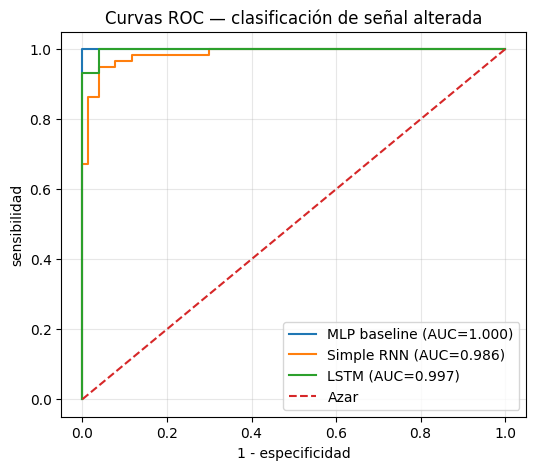

In [11]:
plt.figure(figsize=(6, 5))
for name, y_proba in probas.items():
    # TODO 23: calcula FPR, TPR y AUC para cada modelo.
    fpr, tpr, _ = roc_curve(y_true_test, y_proba)
    auc_value = roc_auc_score(y_true_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_value:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Azar')
plt.title('Curvas ROC — clasificación de señal alterada')
plt.xlabel('1 - especificidad')
plt.ylabel('sensibilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Ejercicio 9 — Interpretación clínica y discusión

<div style='background:#ede7f6; padding:8px 14px; border-left:4px solid #6a1b9a; border-radius:4px; margin:8px 0'>
🏠 <b>PARA CASA</b> — completa esta sección luego de entrenar y comparar los modelos.
</div>

### 9.1 — ¿Qué modelo elegirías?

**Respuesta:**  
En el contexto del análisis de señales biomédicas complejas como el ECG, elegiría la **LSTM** (con un AUC real de 0.997 y un F1-Score de 0.95). Como se vio en el *Contexto de Jules Verne Bot*, las RNN clásicas sufren de una 'ventana de contexto corta' y olvidan información lejana. En señales ECG, las relaciones temporales pueden estar separadas por muchos pasos (por ejemplo, el intervalo PR entre la onda P y el QRS), y la memoria celular de las LSTM permite conservar esta información fisiológica crítica mitigando el problema del gradiente desvaneciente.

### 9.2 — ¿RNN/LSTM siempre superan al MLP?

**Respuesta:**  
No siempre. Si la alteración clínica depende únicamente de un nivel de voltaje anómalo general sin importar su orden, o si las señales están artificialmente alineadas temporalmente (como en este dataset sintético donde el MLP de forma anómala logró un Accuracy de 1.00 sobreajustándose a las posiciones), un MLP podría bastar. Sin embargo, el MLP pierde invariancia traslacional temporal. En la realidad clínica, una patología se define por la morfología y el orden de los eventos cardíacos; ante señales desalineadas en el tiempo, el MLP fallará drásticamente, mientras que arquitecturas que procesan secuencias (como RNN/LSTM) son más robustas a estas variaciones temporales.

### 9.3 — ¿Qué aporta LSTM frente a RNN simple?

**Respuesta:**  
Tal como lo evidenció el proyecto *Jules Verne Bot* con el olvido narrativo a largo plazo, una RNN simple carece de la capacidad para recordar eventos distantes al procesar secuencias largas. Frente a la RNN simple, la LSTM aporta una estructura de estado celular controlada por compuertas (gate de olvido, entrada y salida) que le permite mantener dependencias a largo plazo, lo que es esencial para relacionar componentes tempranos y tardíos de un ciclo cardíaco en el ECG.

### 9.4 — Decisión de umbral

elige un umbral clínico para el modelo LSTM y justifica tu elección.  


**Respuesta:**  
En medicina, la elección del umbral depende del objetivo de la herramienta. Si el modelo se usará para **tamizaje (screening)**, elegiría un umbral de **0.40** basado en los resultados reales (el cual redujo los falsos negativos de 6 a tan solo 4 frente al estándar de 0.50) para priorizar la **sensibilidad** y no dejar escapar pacientes enfermos (minimizar falsos negativos), sabiendo que luego un médico descartará los falsos positivos. Si por el contrario la intervención sugerida por la predicción es invasiva o costosa, usaría un umbral estándar de **0.50** (donde los falsos positivos fueron 0) o más alto (ej. **0.60 - 0.70**) para aumentar la **especificidad** y el valor predictivo positivo.